# Control continuo con aproximación

<a href="https://colab.research.google.com/github/NaoKB/EML/blob/main/Entornos_Complejos/03_control_continuo_aproximado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

ThermalGlider exige alcanzar la zona de aterrizaje sin exceso de velocidad,
temperatura ni consumo de bateria. La pregunta experimental es si la estrategia
mas eficiente con viento nominal sigue siendo segura cuando aumenta la
turbulencia.

In [1]:
from pathlib import Path
import subprocess
import sys

candidates = [
    Path.cwd(),
    Path.cwd() / "Entornos_Complejos",
    Path("/content/EML/Entornos_Complejos"),
]
ROOT = next((path.resolve() for path in candidates if (path / "src").is_dir()), None)
if ROOT is None:
    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/NaoKB/EML.git", "/content/EML"],
        check=True,
    )
    ROOT = Path("/content/EML/Entornos_Complejos")
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / "results"
print(f"Proyecto: {ROOT}")

from src.artifacts import result_path

def result(name):
    return result_path(RESULTS, name)

Proyecto: C:\Users\Joaquín\Desktop\EML\Entornos_Complejos


## Métodos y protocolo

- Referencia Q-Learning con solo 16 estados discretizados.
- SARSA semi-gradiente con 8 mosaicos de tile coding.
- Deep Q-Learning con red de dos capas, repeticion de experiencias y red objetivo.
- 1200 episodios, 3 semillas y 250 evaluaciones por semilla.
- Viento nominal frente a turbulencia multiplicada por 2.3.

In [2]:
import pandas as pd

summary = pd.read_csv(result("approx_summary.csv"))
table = summary.copy()
table["success_rate"] = (100 * table["success_rate"]).round(1)
table["risk_rate"] = (100 * table["risk_rate"]).round(1)
table[["mean_return", "mean_length"]] = table[["mean_return", "mean_length"]].round(2)
table.rename(columns={"success_rate": "exito_%", "risk_rate": "riesgo_%"}).sort_values(
    ["condition", "riesgo_%"]
)

Faltan resultados aproximados base; se regenerara el estudio ThermalGlider.


,study,agent,condition,mean_return,mean_length,exito_%,riesgo_%
0,aproximado,Deep Q-Learning,turbulencia x2.3,18.86,17.17,98.0,2.5
2,aproximado,Q-Learning discretizado,turbulencia x2.3,18.44,19.13,96.9,6.7
4,aproximado,SARSA semi-gradiente,turbulencia x2.3,18.10,12.28,94.5,10.0
1,aproximado,Deep Q-Learning,viento nominal,19.32,16.67,99.6,0.4
5,aproximado,SARSA semi-gradiente,viento nominal,19.41,11.70,99.5,1.9
3,aproximado,Q-Learning discretizado,viento nominal,19.18,19.52,99.7,2.3


## Aprendizaje y robustez

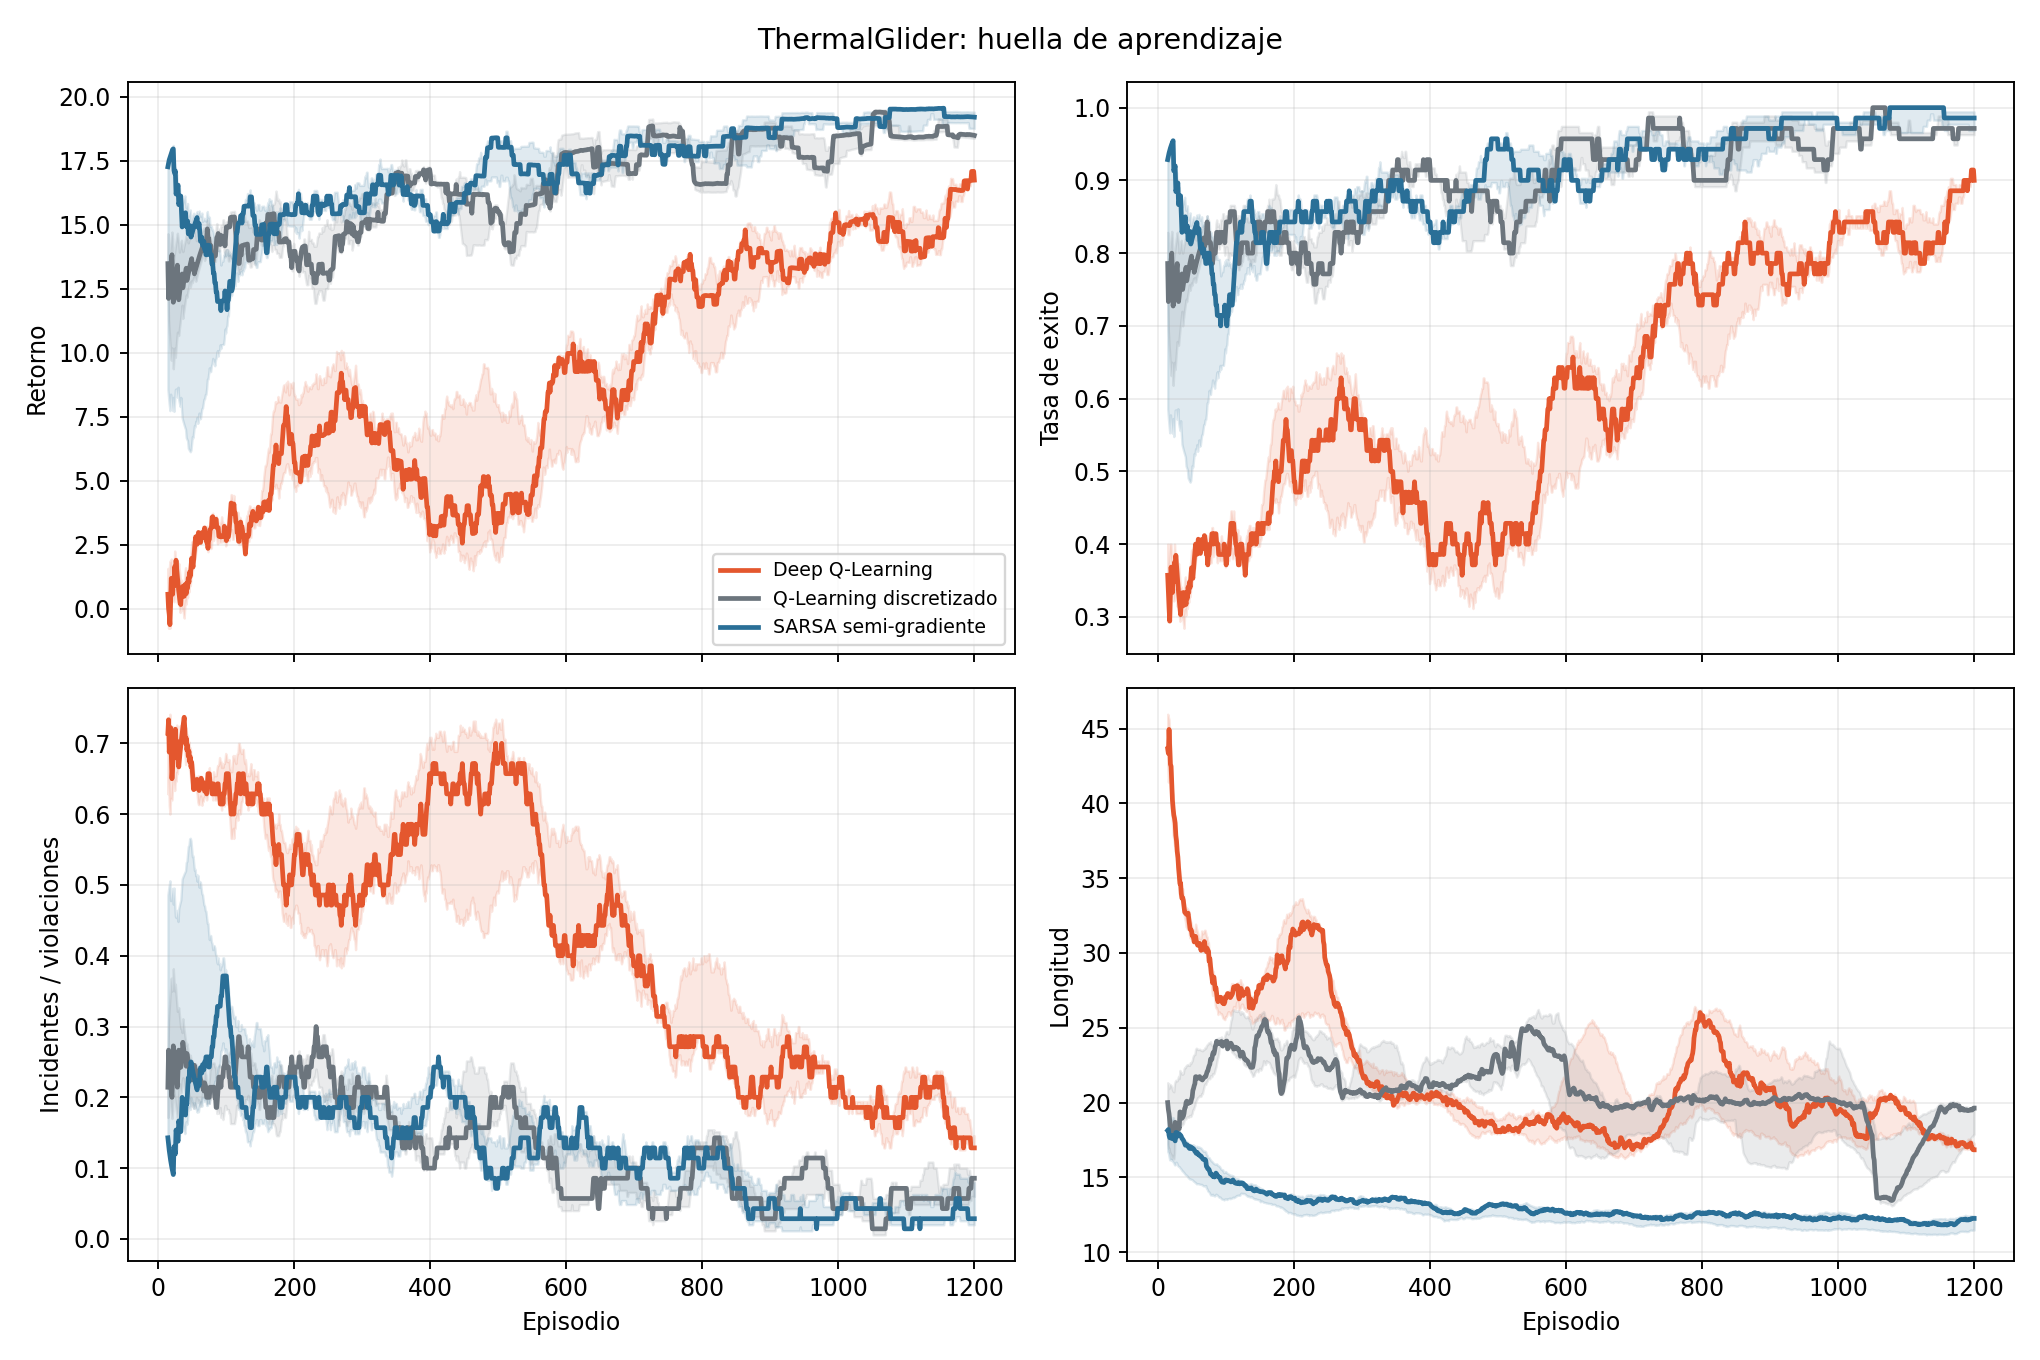

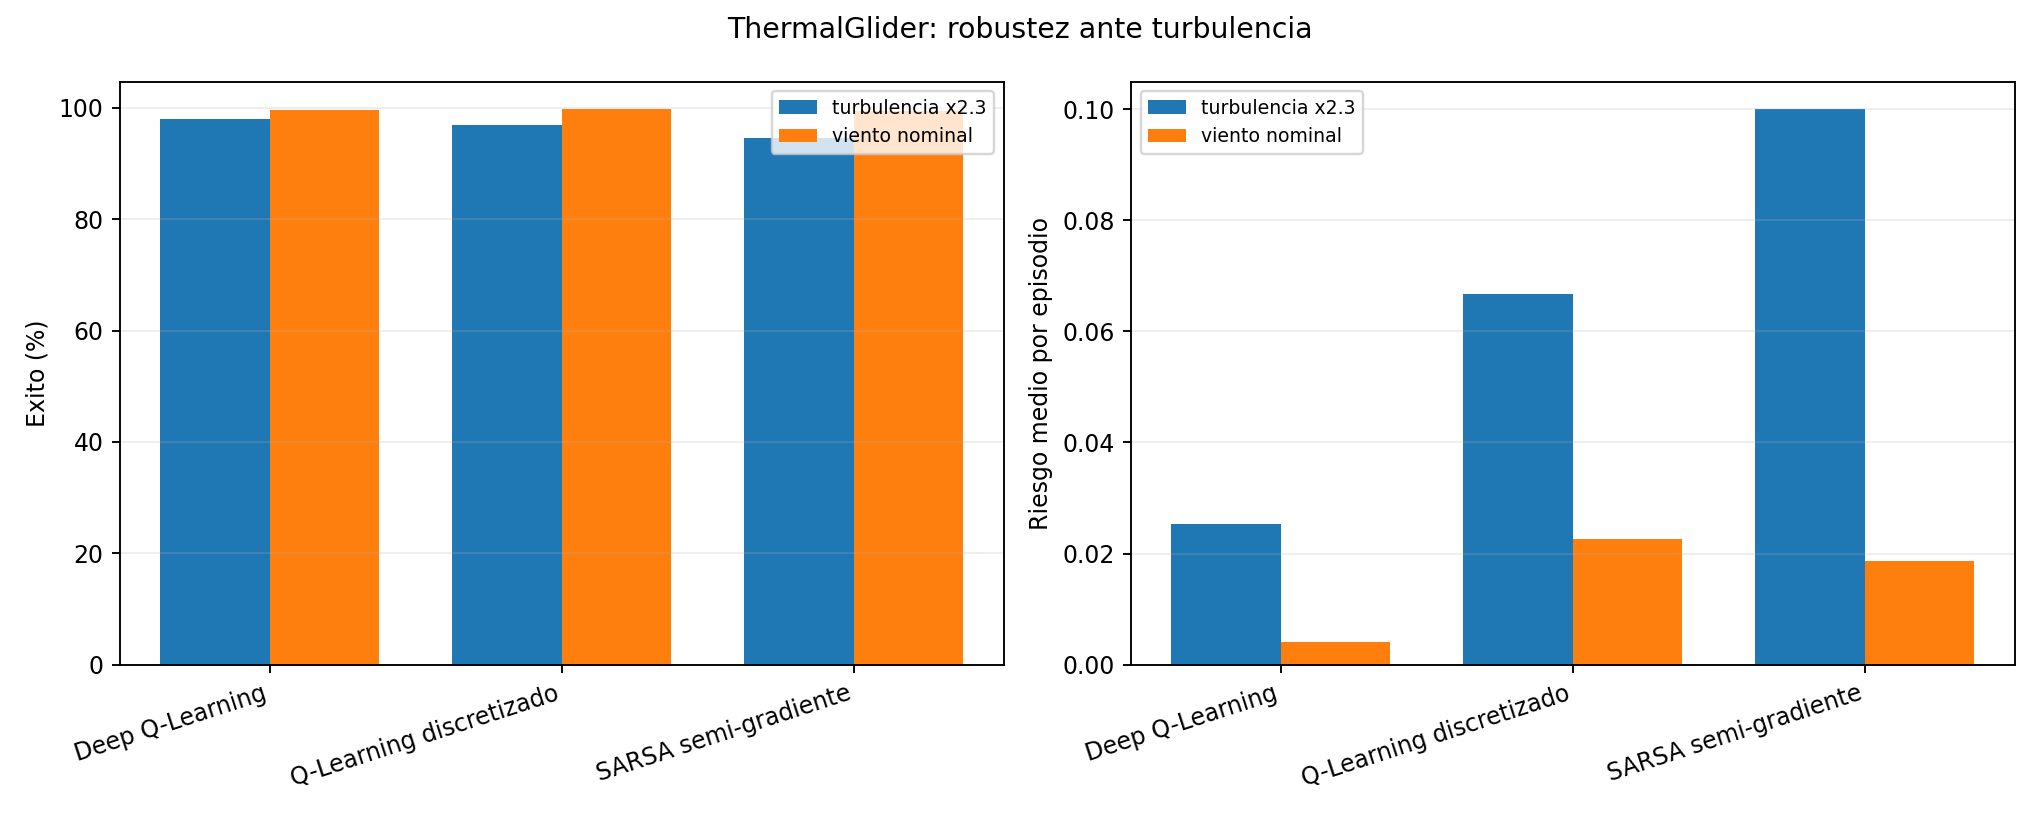

In [3]:
from IPython.display import Image, display

def show_result(name):
    display(Image(filename=str(result(name))))

show_result("approx_learning_fingerprint.png")
show_result("approx_robustness.png")

SARSA semi-gradiente aprende rapido y produce episodios muy
cortos, pero bajo turbulencia su riesgo llega al 10% y el exito baja al 94.5%.
DQN aprende con mas ruido y termina usando mas pasos; aun asi conserva 98% de exito
y solo 2.5% de riesgo bajo turbulencia. La referencia discretizada resuelve muchos
episodios, pero es mas lenta y su riesgo aumenta al 6.7%, un efecto coherente con
el aliasing de estados.

## Trayectorias

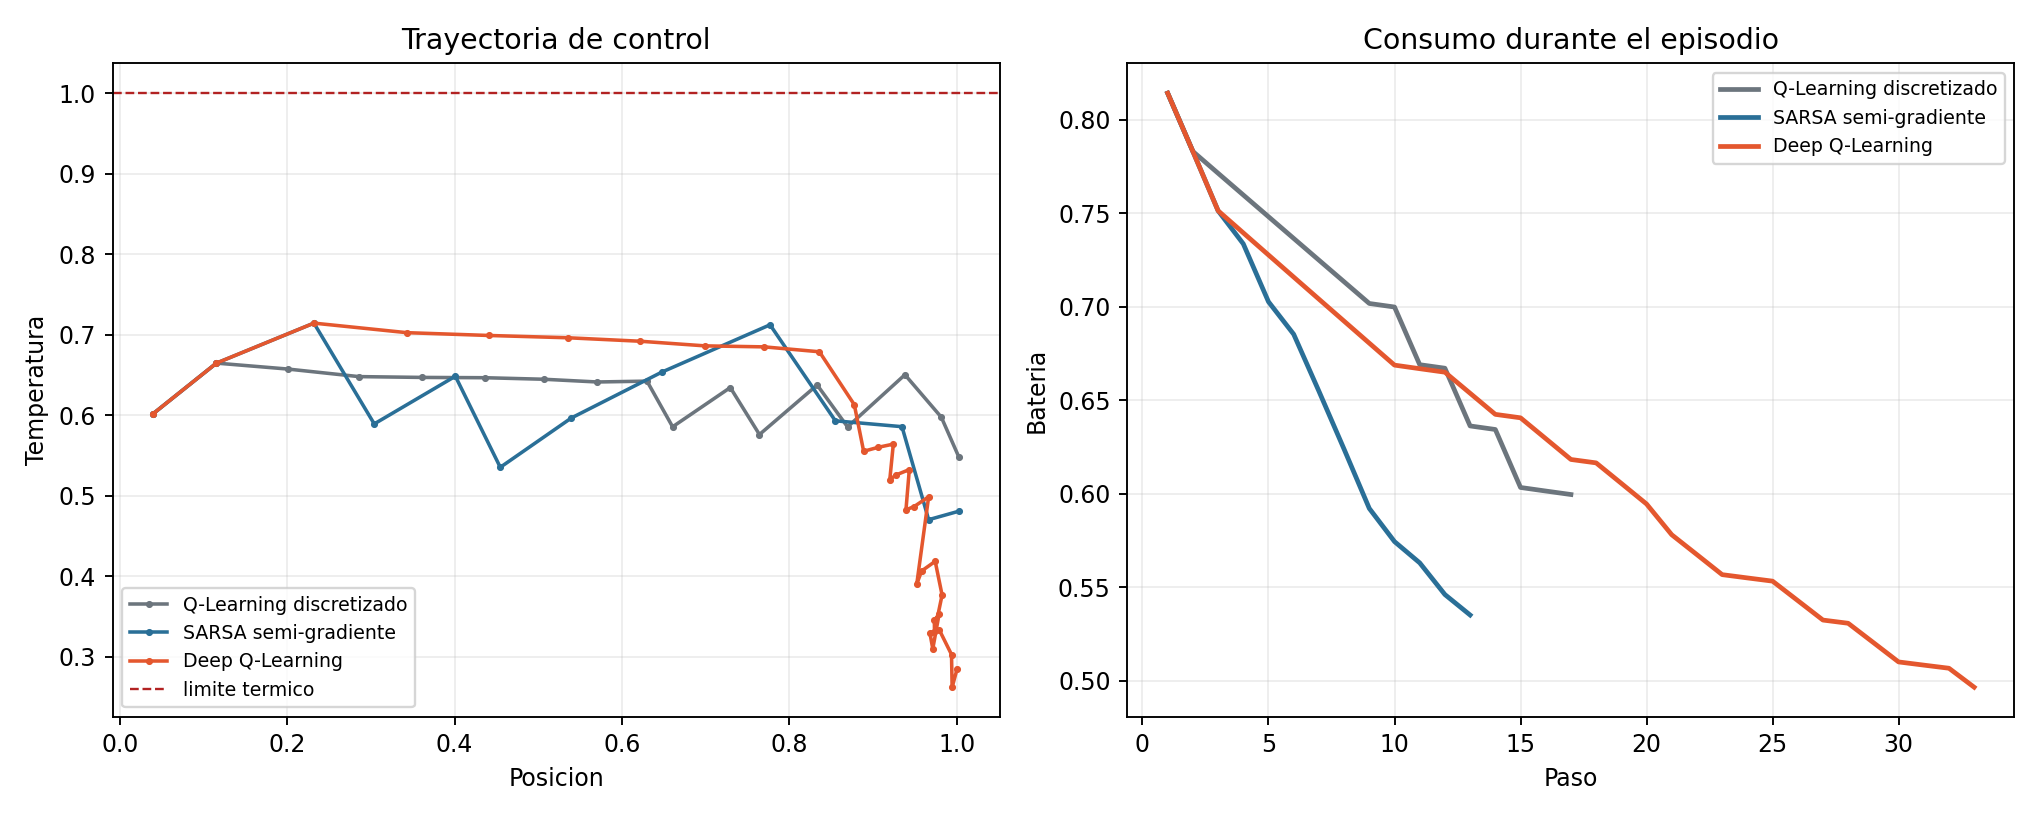

In [4]:
from IPython.display import Image, display

def show_result(name):
    display(Image(filename=str(result(name))))

show_result("continuous_trajectories.png")

Las trayectorias hacen visible el compromiso que las medias
ocultan. SARSA semi-gradiente avanza de forma agresiva y termina pronto; la politica
discretizada necesita mas correcciones; DQN adopta una trayectoria mas conservadora.
La figura no demuestra superioridad por si sola, pues corresponde a episodios
representativos y debe leerse junto con las evaluaciones agregadas.

## Variabilidad entre semillas

In [5]:
by_seed = pd.read_csv(result("approx_evaluation_by_seed.csv"))
by_seed.groupby(["agent", "condition"]).agg(
    exito_minimo=("success_rate", "min"),
    exito_maximo=("success_rate", "max"),
    riesgo_medio=("risk_rate", "mean"),
    riesgo_sd=("risk_rate", "std"),
).round(3)

exito_minimo  exito_maximo  \
agent                   condition                                      
Deep Q-Learning         turbulencia x2.3         0.952         1.000   
                        viento nominal           0.988         1.000   
Q-Learning discretizado turbulencia x2.3         0.936         0.988   
                        viento nominal           0.992         1.000   
SARSA semi-gradiente    turbulencia x2.3         0.912         0.964   
                        viento nominal           0.988         1.000   

                                          riesgo_medio  riesgo_sd  
agent                   condition                                  
Deep Q-Learning         turbulencia x2.3         0.025      0.023  
                        viento nominal           0.004      0.007  
Q-Learning discretizado turbulencia x2.3         0.067      0.039  
                        viento nominal           0.023      0.032  
SARSA semi-gradiente    turbulencia x2.3         0.100      0.045  
                        viento nominal           0.019      0.018

La aproximacion no elimina la necesidad de evaluar fuera de las
condiciones de entrenamiento. En este estudio, el metodo mas rapido nominalmente no
es el mas robusto, y DQN justifica su mayor coste solo cuando la perturbacion forma
parte de la pregunta.